# Healthcare Analytics for Doctor Visits

### Exploratory Data Analysis (EDA)

This notebook performs **data understanding, data cleaning, univariate analysis, bivariate analysis, multivariate analysis, correlation analysis, and key insights** for the Healthcare Analytics dataset.

**Main tools:** Pandas, NumPy, Matplotlib, Seaborn

## 1. Import Libraries

Import the Python libraries required for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Dataset

The code first looks for a CSV file in the notebook's current folder. If there is only one CSV file, it loads that file automatically.

**Tip:** Keep the CSV file in the same folder as this `.ipynb` file for easy execution.

In [2]:
csv_files = list(Path('.').glob('*.csv'))

if len(csv_files) == 0:
    raise FileNotFoundError(
        'No CSV file found. Put the Healthcare Analytics CSV in the same folder as this notebook.'
    )

if len(csv_files) > 1:
    print('CSV files found:')
    for i, file in enumerate(csv_files, 1):
        print(f'{i}. {file.name}')
    print('\nUsing the first CSV file. Change csv_path below if needed.')

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print(f'Dataset loaded: {csv_path.name}')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded: 1776250375-P2-Healthcare Analytics for Doctor Visits (1) (1).csv
Shape: (5190, 13)


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 3. Understand the Dataset

Check the number of rows and columns, column names, data types, and basic statistics.

In [3]:
print('Rows and Columns:', df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print('\nData Types:')
print(df.dtypes)

print('\nDataset Information:')
df.info()

print('\nSummary Statistics:')
display(df.describe(include='all').T)

Rows and Columns: (5190, 13)

Column Names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

Data Types:
Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,NaN,NaN,NaN,2595.5,1498.368279,1.0,1298.25,2595.5,3892.75,5190.0
visits,5190.0,NaN,NaN,NaN,0.301734,0.798134,0.0,0.0,0.0,0.0,9.0
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5190.0,NaN,NaN,NaN,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,NaN,NaN,NaN,0.58316,0.368907,0.0,0.25,0.55,0.9,1.5
illness,5190.0,NaN,NaN,NaN,1.431985,1.384152,0.0,0.0,1.0,2.0,5.0
reduced,5190.0,NaN,NaN,NaN,0.86185,2.887628,0.0,0.0,0.0,0.0,14.0
health,5190.0,NaN,NaN,NaN,1.217534,2.124266,0.0,0.0,0.0,2.0,12.0
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

Remove unwanted index-like columns, check missing values, and check duplicate rows.

In [4]:
# Remove common unwanted index columns if they exist
index_like = [col for col in df.columns if str(col).lower().startswith('unnamed')]
if index_like:
    df = df.drop(columns=index_like)
    print('Removed:', index_like)

print('\nMissing Values:')
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame('Missing Values'))

print('Duplicate Rows:', df.duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print('Shape after cleaning:', df.shape)

Removed: ['Unnamed: 0']

Missing Values:


,Missing Values
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0
freerepat,0


Duplicate Rows: 1320
Shape after cleaning: (3870, 12)


## 5. Data Type and Category Check

Display unique values for categorical columns. This helps understand how the dataset represents gender, health, illness, and healthcare-access variables.

In [5]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False).head(20))


gender:
gender
female    2068
male      1802
Name: count, dtype: int64

private:
private
no     2088
yes    1782
Name: count, dtype: int64

freepoor:
freepoor
no     3676
yes     194
Name: count, dtype: int64

freerepat:
freerepat
no     3102
yes     768
Name: count, dtype: int64

nchronic:
nchronic
no     2192
yes    1678
Name: count, dtype: int64

lchronic:
lchronic
no     3294
yes     576
Name: count, dtype: int64


# 6. Univariate Analysis

**Univariate analysis** studies one variable at a time.

### 6.1 Doctor Visits Distribution

The `visits` variable represents the number of doctor visits.

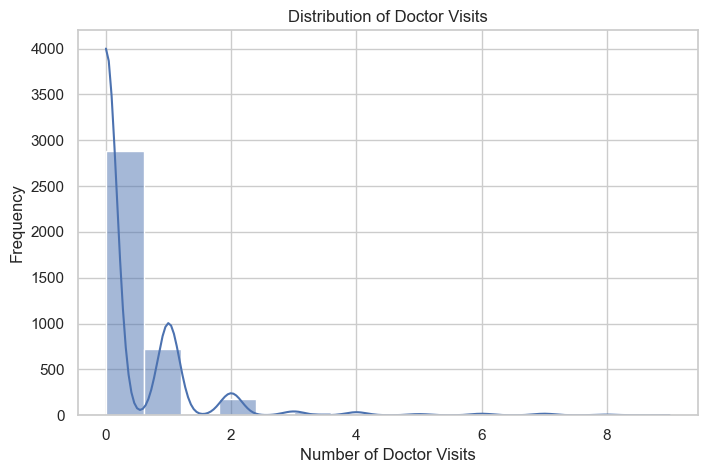

In [6]:
if 'visits' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['visits'].dropna(), bins=15, kde=True)
    plt.title('Distribution of Doctor Visits')
    plt.xlabel('Number of Doctor Visits')
    plt.ylabel('Frequency')
    plt.show()
else:
    print('Column visits not found.')

### 6.2 Gender Distribution

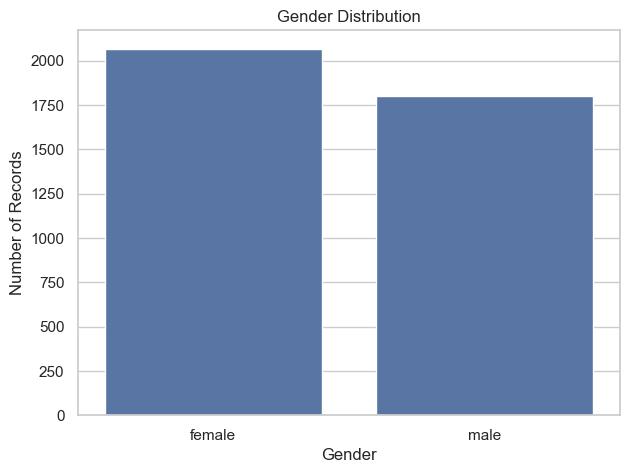

,Count
gender,
female,2068
male,1802


In [7]:
if 'gender' in df.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x='gender')
    plt.title('Gender Distribution')
    plt.xlabel('Gender')
    plt.ylabel('Number of Records')
    plt.show()
    display(df['gender'].value_counts().to_frame('Count'))
else:
    print('Column gender not found.')

### 6.3 Age Distribution

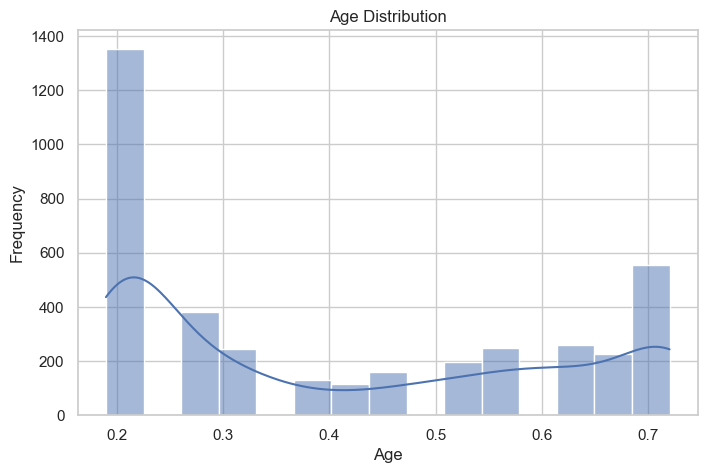

,Age Statistics
count,3870.000000
mean,0.410762
std,0.200034
min,0.190000
25%,0.220000
50%,0.320000
75%,0.620000
max,0.720000


In [8]:
if 'age' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['age'].dropna(), bins=15, kde=True)
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()
    display(df['age'].describe().to_frame('Age Statistics'))
else:
    print('Column age not found.')

### 6.4 Income Distribution

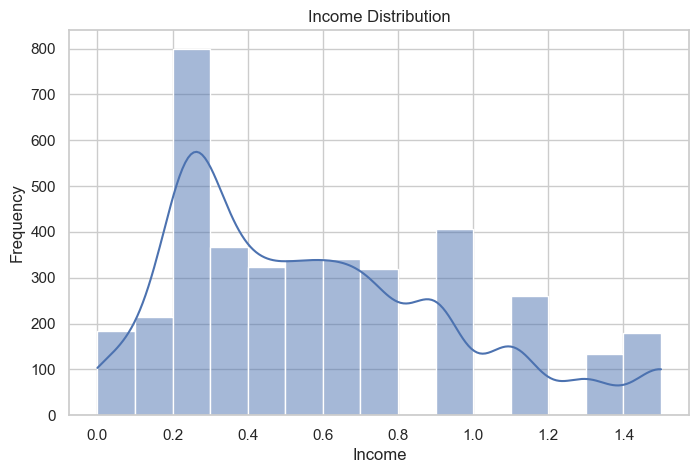

In [9]:
if 'income' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['income'].dropna(), bins=15, kde=True)
    plt.title('Income Distribution')
    plt.xlabel('Income')
    plt.ylabel('Frequency')
    plt.show()
else:
    print('Column income not found.')

### 6.5 Illness and Health Status Distribution

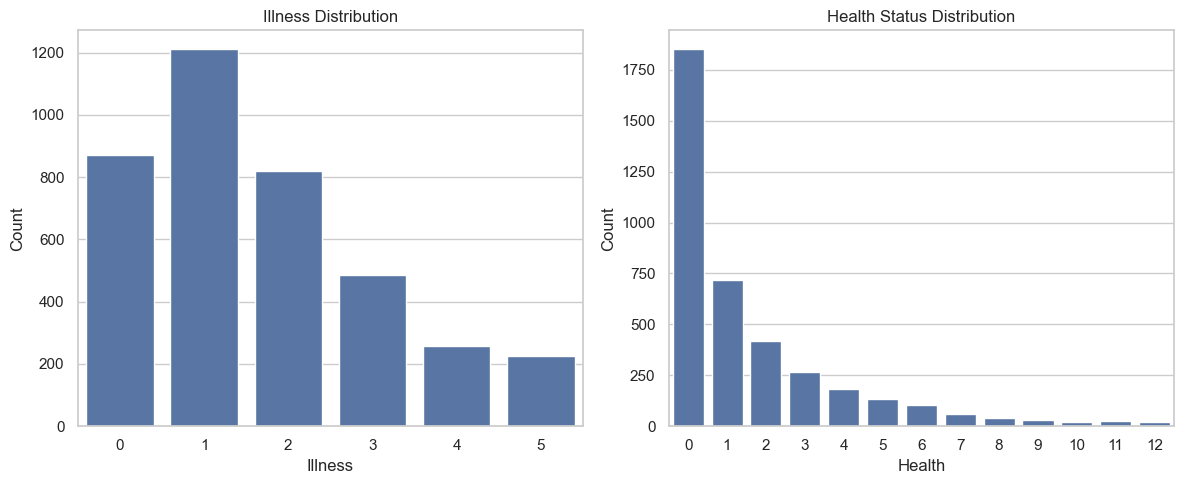

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if 'illness' in df.columns:
    sns.countplot(data=df, x='illness', ax=axes[0])
    axes[0].set_title('Illness Distribution')
    axes[0].set_xlabel('Illness')
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'illness column not found', ha='center')
    axes[0].set_axis_off()

if 'health' in df.columns:
    sns.countplot(data=df, x='health', ax=axes[1])
    axes[1].set_title('Health Status Distribution')
    axes[1].set_xlabel('Health')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'health column not found', ha='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### 6.6 Chronic Disease Distribution

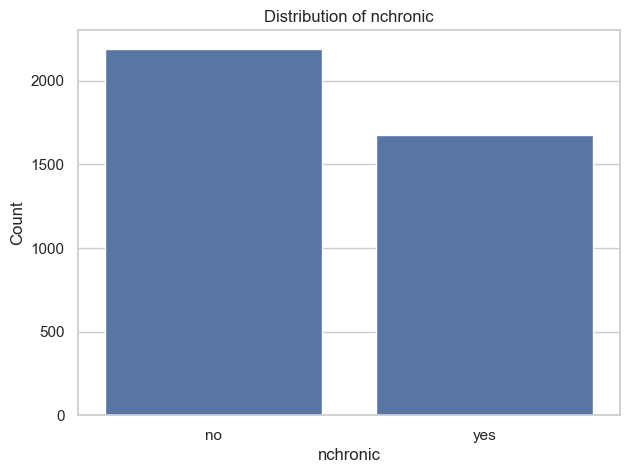

,Count
nchronic,
no,2192
yes,1678


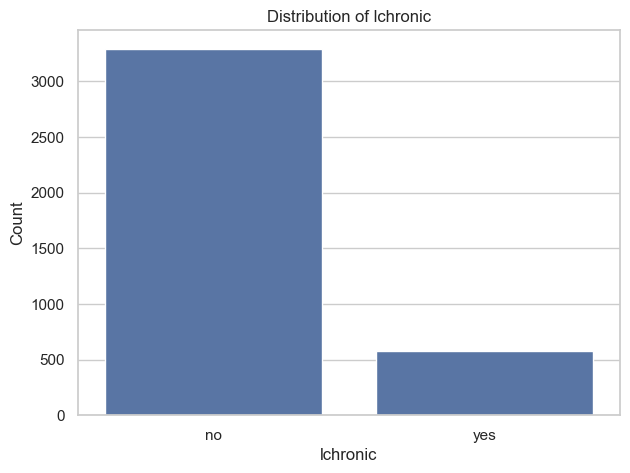

,Count
lchronic,
no,3294
yes,576


In [11]:
chronic_cols = [col for col in ['nchronic', 'lchronic'] if col in df.columns]

for col in chronic_cols:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
    display(df[col].value_counts().sort_index().to_frame('Count'))

# 7. Bivariate Analysis

**Bivariate analysis** studies the relationship between two variables.

### 7.1 Gender vs Doctor Visits

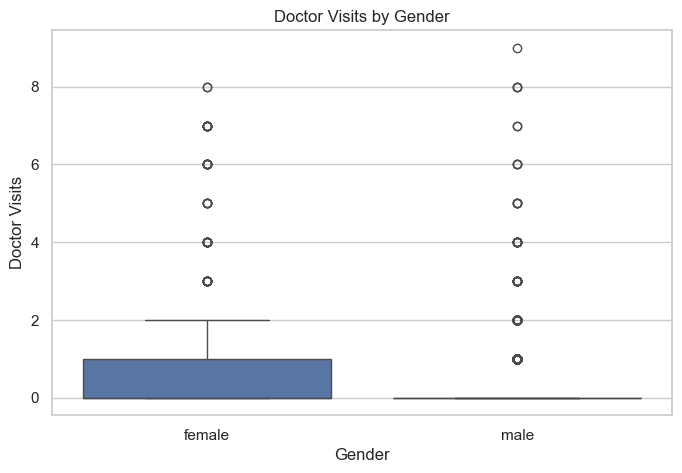

,count,mean,median,max
gender,,,,
female,2068,0.45,0.0,8
male,1802,0.32,0.0,9


In [12]:
if {'gender', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='gender', y='visits')
    plt.title('Doctor Visits by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Doctor Visits')
    plt.show()

    display(df.groupby('gender')['visits'].agg(['count', 'mean', 'median', 'max']).round(2))
else:
    print('Required columns not found.')

### 7.2 Age vs Doctor Visits

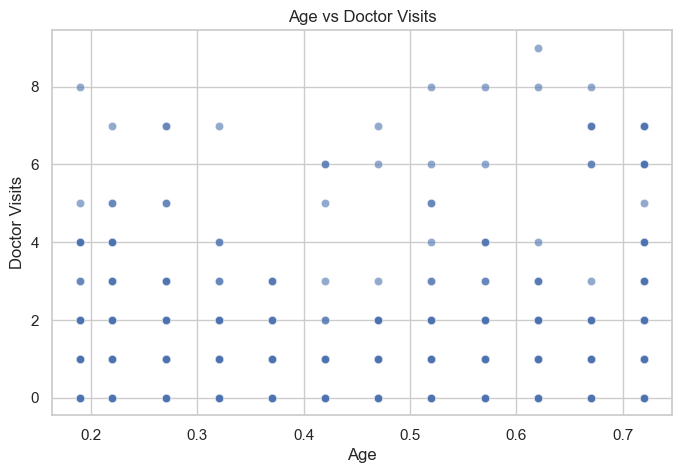

Correlation between age and visits:
0.124


In [13]:
if {'age', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='age', y='visits', alpha=0.6)
    plt.title('Age vs Doctor Visits')
    plt.xlabel('Age')
    plt.ylabel('Doctor Visits')
    plt.show()

    print('Correlation between age and visits:')
    print(df[['age', 'visits']].corr().iloc[0, 1].round(3))
else:
    print('Required columns not found.')

### 7.3 Income vs Doctor Visits

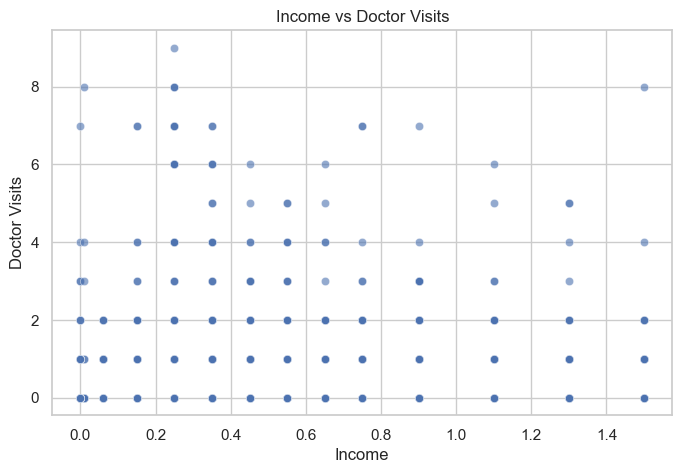

In [14]:
if {'income', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='income', y='visits', alpha=0.6)
    plt.title('Income vs Doctor Visits')
    plt.xlabel('Income')
    plt.ylabel('Doctor Visits')
    plt.show()
else:
    print('Required columns not found.')

### 7.4 Illness vs Doctor Visits

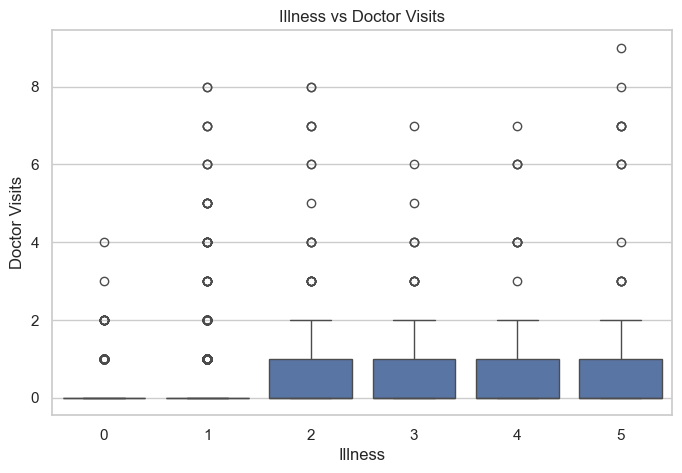

,count,mean,median
illness,,,
0,870,0.13,0.0
1,1211,0.38,0.0
2,821,0.45,0.0
3,485,0.45,0.0
4,258,0.61,0.0
5,225,0.85,0.0


In [15]:
if {'illness', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='illness', y='visits')
    plt.title('Illness vs Doctor Visits')
    plt.xlabel('Illness')
    plt.ylabel('Doctor Visits')
    plt.show()

    display(df.groupby('illness')['visits'].agg(['count', 'mean', 'median']).round(2))
else:
    print('Required columns not found.')

### 7.5 Health Status vs Doctor Visits

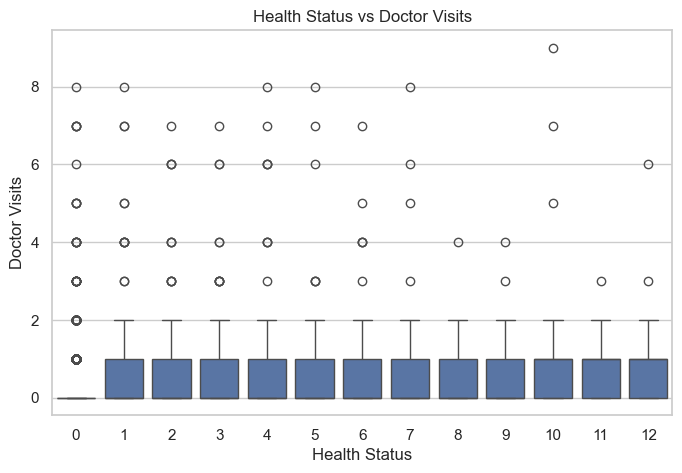

,count,mean,median
health,,,
0,1851,0.30,0.0
1,719,0.37,0.0
2,419,0.40,0.0
3,264,0.42,0.0
4,185,0.54,0.0
5,132,0.53,0.0
6,102,0.64,0.0
7,61,0.92,0.0
8,41,0.49,0.0


In [16]:
if {'health', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='health', y='visits')
    plt.title('Health Status vs Doctor Visits')
    plt.xlabel('Health Status')
    plt.ylabel('Doctor Visits')
    plt.show()

    display(df.groupby('health')['visits'].agg(['count', 'mean', 'median']).round(2))
else:
    print('Required columns not found.')

# 8. Multivariate Analysis

**Multivariate analysis** examines three or more variables together.

### 8.1 Age + Income + Doctor Visits

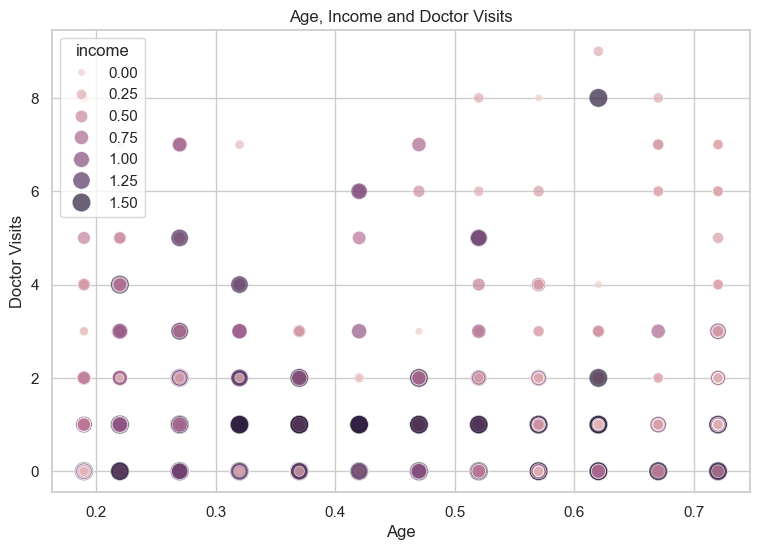

In [17]:
if {'age', 'income', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df,
        x='age',
        y='visits',
        hue='income',
        size='income',
        sizes=(30, 180),
        alpha=0.7
    )
    plt.title('Age, Income and Doctor Visits')
    plt.xlabel('Age')
    plt.ylabel('Doctor Visits')
    plt.show()
else:
    print('Required columns not found.')

### 8.2 Illness + Health + Doctor Visits

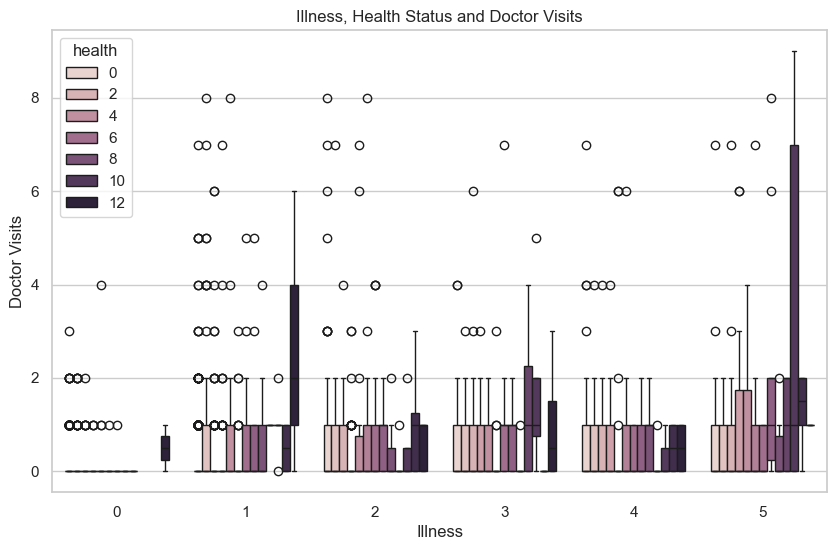

In [18]:
if {'illness', 'health', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='illness', y='visits', hue='health')
    plt.title('Illness, Health Status and Doctor Visits')
    plt.xlabel('Illness')
    plt.ylabel('Doctor Visits')
    plt.show()
else:
    print('Required columns not found.')

### 8.3 Gender + Health + Doctor Visits

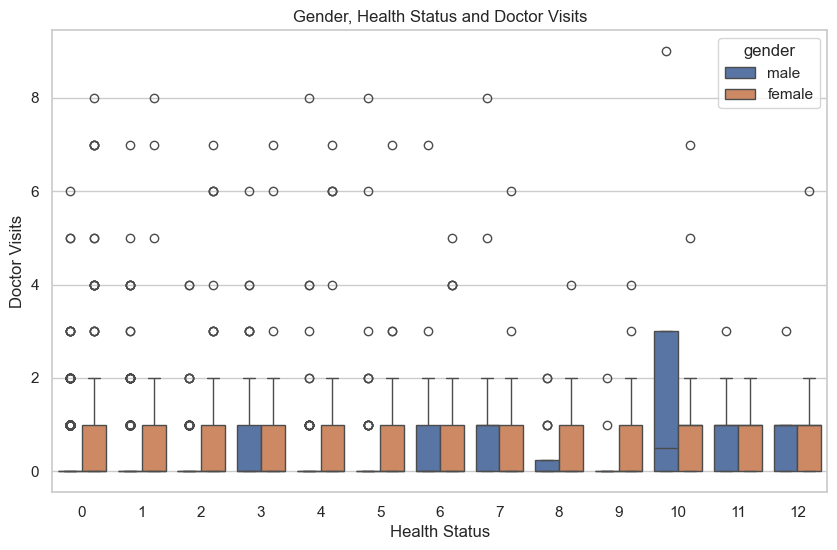

In [19]:
if {'gender', 'health', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='health', y='visits', hue='gender')
    plt.title('Gender, Health Status and Doctor Visits')
    plt.xlabel('Health Status')
    plt.ylabel('Doctor Visits')
    plt.show()
else:
    print('Required columns not found.')

### 8.4 Chronic Disease + Health + Doctor Visits

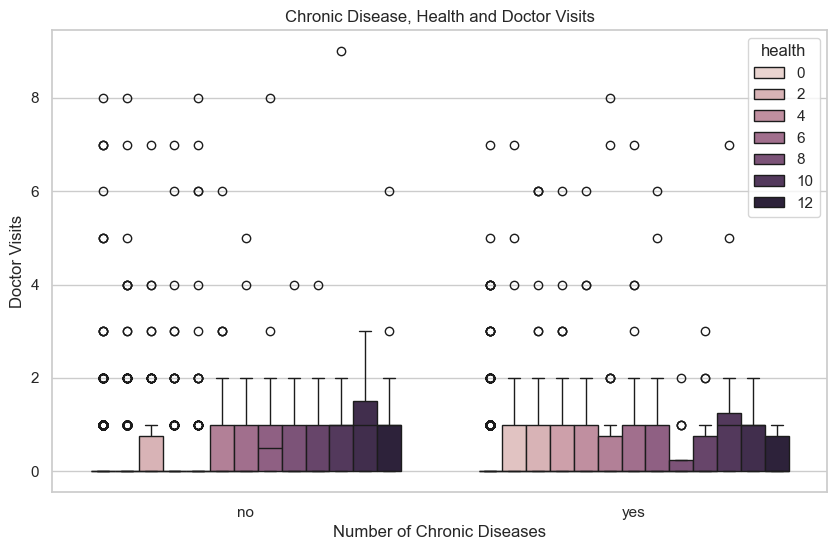

In [20]:
if {'nchronic', 'health', 'visits'}.issubset(df.columns):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='nchronic', y='visits', hue='health')
    plt.title('Chronic Disease, Health and Doctor Visits')
    plt.xlabel('Number of Chronic Diseases')
    plt.ylabel('Doctor Visits')
    plt.show()
else:
    print('Required columns not found.')

# 9. Correlation Analysis

Correlation helps identify linear relationships among numerical variables.

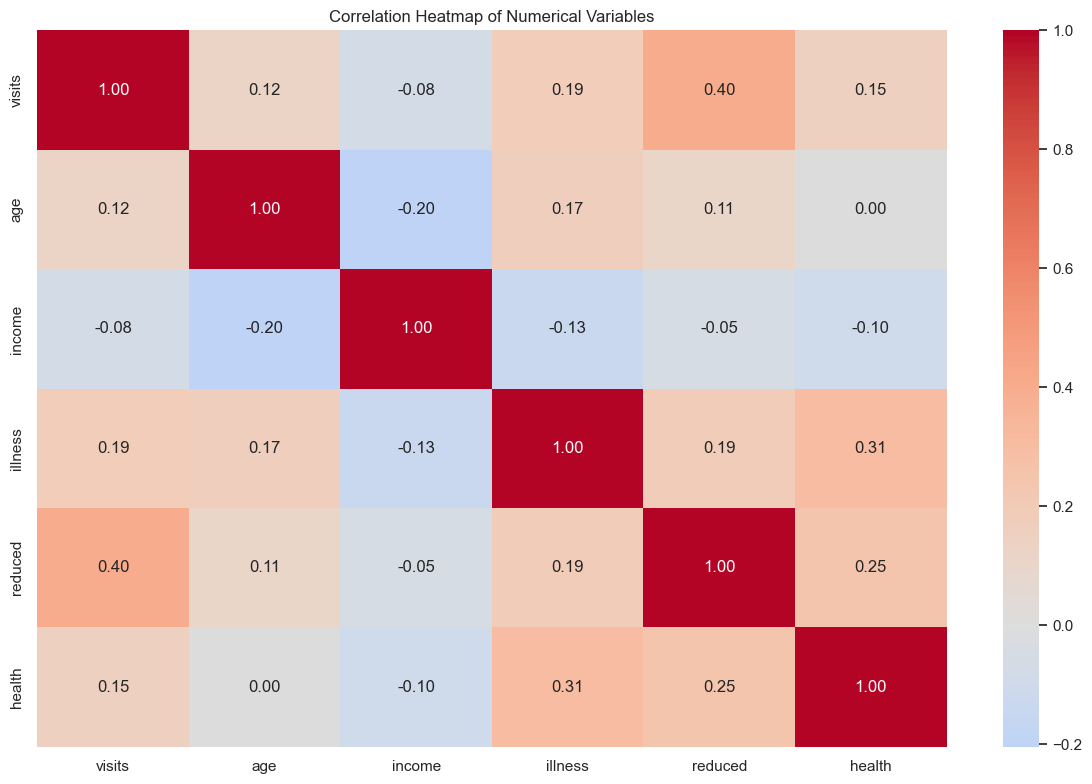

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

# 10. Doctor Visits: Important Group Comparisons

This section summarizes average doctor visits across important demographic and health-related variables.

In [22]:
group_columns = [
    col for col in ['gender', 'illness', 'health', 'nchronic', 'lchronic', 'reduced', 'private', 'freepoor', 'freerepat']
    if col in df.columns
]

for col in group_columns:
    if 'visits' in df.columns:
        print(f'\nAverage doctor visits by {col}:')
        display(df.groupby(col)['visits'].agg(['count', 'mean', 'median', 'max']).round(2))


Average doctor visits by gender:


,count,mean,median,max
gender,,,,
female,2068,0.45,0.0,8
male,1802,0.32,0.0,9



Average doctor visits by illness:


,count,mean,median,max
illness,,,,
0,870,0.13,0.0,4
1,1211,0.38,0.0,8
2,821,0.45,0.0,8
3,485,0.45,0.0,7
4,258,0.61,0.0,7
5,225,0.85,0.0,9



Average doctor visits by health:


...

,count,mean,median,max
private,,,,
no,2088,0.40,0.0,9
yes,1782,0.37,0.0,8



Average doctor visits by freepoor:


,count,mean,median,max
freepoor,,,,
no,3676,0.40,0.0,9
yes,194,0.18,0.0,7



Average doctor visits by freerepat:


,count,mean,median,max
freerepat,,,,
no,3102,0.33,0.0,8
yes,768,0.61,0.0,9


# 11. Key Insights Summary

Use the outputs above to write project-specific findings. The code below generates a few automatic summaries without assuming a particular result.

In [23]:
print('KEY DATASET SUMMARY')
print('-' * 40)
print(f'Total records: {len(df):,}')
print(f'Total columns: {df.shape[1]}')

if 'visits' in df.columns:
    print(f'Average doctor visits: {df["visits"].mean():.2f}')
    print(f'Median doctor visits: {df["visits"].median():.2f}')
    print(f'Maximum doctor visits: {df["visits"].max():.2f}')

if 'age' in df.columns:
    print(f'Average age: {df["age"].mean():.2f}')

print('\nRecommended final report points:')
print('1. Describe the overall distribution of doctor visits.')
print('2. Compare doctor visits across gender, illness and health status.')
print('3. Examine age and income relationships with doctor visits.')
print('4. Analyze chronic disease and reduced-activity patterns.')
print('5. Use the correlation heatmap to discuss numerical relationships.')
print('6. Add only findings that are directly supported by the charts and tables.')

KEY DATASET SUMMARY
----------------------------------------
Total records: 3,870
Total columns: 12
Average doctor visits: 0.39
Median doctor visits: 0.00
Maximum doctor visits: 9.00
Average age: 0.41

Recommended final report points:
1. Describe the overall distribution of doctor visits.
2. Compare doctor visits across gender, illness and health status.
3. Examine age and income relationships with doctor visits.
4. Analyze chronic disease and reduced-activity patterns.
5. Use the correlation heatmap to discuss numerical relationships.
6. Add only findings that are directly supported by the charts and tables.


# 12. Conclusion

This exploratory analysis studies healthcare utilization through **univariate, bivariate and multivariate analysis**. It examines demographic factors, health conditions, chronic diseases, income and healthcare-related variables in relation to doctor visits.

The final conclusions should be written from the actual results produced by the notebook rather than assuming that one factor causes another.